In [2]:
!pip install -q torch torchvision torchaudio pillow matplotlib scikit-learn



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [10]:
!pip install tqdm



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import torch
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: mps


In [15]:
TRAIN_PATH = "/Users/marieta/Downloads/Birds_25/train"
VALID_PATH   = "/Users/marieta/Downloads/Birds_25/valid"  


In [7]:
TRAIN_DIR

'/Users/marieta/Downloads/Birds_25/train'

In [13]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report
from tqdm import tqdm



In [16]:
train_images = glob.glob(f"{TRAIN_PATH}/*/*")
valid_images = glob.glob(f"{VALID_PATH}/*/*")

print("Train images:", len(train_images))
print("Valid images:", len(valid_images))


Train images: 30000
Valid images: 7500


In [17]:
class CFG:
    EPOCHS = 7
    BATCH_SIZE = 32
    SEED = 42
    HEIGHT = 224
    WIDTH = 224

In [19]:
train_transforms = transforms.Compose([
    transforms.Resize((CFG.HEIGHT, CFG.WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

valid_transforms = transforms.Compose([
    transforms.Resize((CFG.HEIGHT, CFG.WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])


In [20]:
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transforms)
valid_dataset = datasets.ImageFolder(VALID_PATH, transform=valid_transforms)

train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)

num_classes = len(train_dataset.classes)
class_names = train_dataset.classes

print("Number of classes:", num_classes)
print("First classes:", class_names[:10])


Number of classes: 25
First classes: ['Asian-Green-Bee-Eater', 'Brown-Headed-Barbet', 'Cattle-Egret', 'Common-Kingfisher', 'Common-Myna', 'Common-Rosefinch', 'Common-Tailorbird', 'Coppersmith-Barbet', 'Forest-Wagtail', 'Gray-Wagtail']


In [21]:
model_vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze convolutional layers (features)
for param in model_vgg.features.parameters():
    param.requires_grad = False


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/marieta/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100.0%


In [22]:
model_vgg.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.BatchNorm1d(4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(4096, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(1024, num_classes)
)

model_vgg = model_vgg.to(device)


In [23]:
criterion = nn.CrossEntropyLoss()

# Only classifier params are trainable (features are frozen)
optimizer = optim.Adam(model_vgg.classifier.parameters(), lr=1e-4)


In [24]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix(loss=running_loss/total, acc=correct/total)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validate ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs} | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

    return history


In [25]:
history = train_model(model_vgg, train_loader, valid_loader, criterion, optimizer, epochs=CFG.EPOCHS)


Epoch 1/7: 100%|████████| 938/938 [09:55<00:00,  1.58it/s, acc=0.81, loss=0.742]



Epoch 1/7 | Train Loss 0.7415 Acc 0.8099 | Val Loss 0.2873 Acc 0.9203


Epoch 2/7: 100%|███████| 938/938 [10:20<00:00,  1.51it/s, acc=0.909, loss=0.328]



Epoch 2/7 | Train Loss 0.3277 Acc 0.9090 | Val Loss 0.2255 Acc 0.9345


Epoch 3/7: 100%|███████| 938/938 [11:04<00:00,  1.41it/s, acc=0.927, loss=0.248]


...


Epoch 5/7 | Train Loss 0.1831 Acc 0.9446 | Val Loss 0.1748 Acc 0.9440


Epoch 6/7: 100%|███████| 938/938 [10:17<00:00,  1.52it/s, acc=0.951, loss=0.162]



Epoch 6/7 | Train Loss 0.1624 Acc 0.9508 | Val Loss 0.1783 Acc 0.9459


Epoch 7/7: 100%|███████| 938/938 [10:35<00:00,  1.48it/s, acc=0.956, loss=0.144]



Epoch 7/7 | Train Loss 0.1436 Acc 0.9558 | Val Loss 0.1674 Acc 0.9489


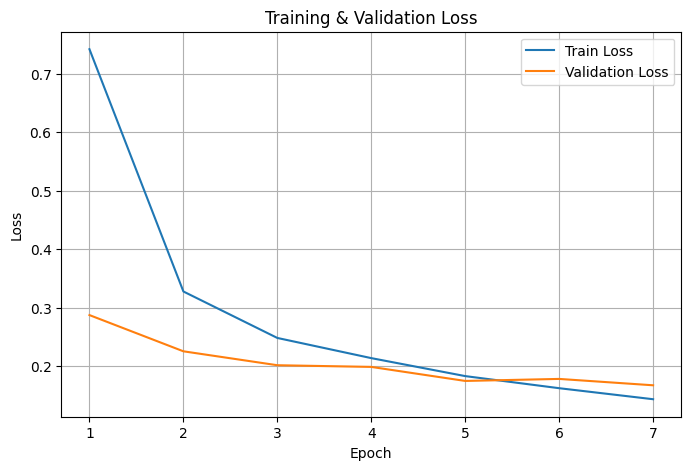

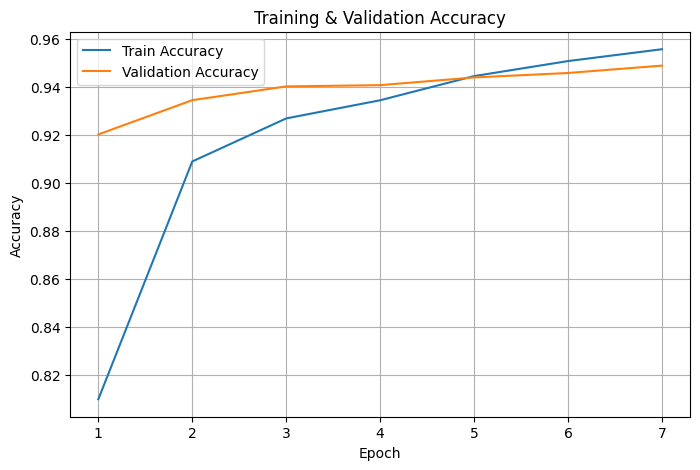

In [26]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()



In [27]:
MODEL_PATH = "vgg16_birds.pth"

torch.save({
    "model_state_dict": model_vgg.state_dict(),
    "class_to_idx": train_dataset.class_to_idx
}, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

Model saved to vgg16_birds.pth


In [188]:
MODEL_PATH = "vgg16_birds.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)

# Rebuild the same VGG architecture
model_loaded = models.vgg16(weights=None)

model_loaded.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.BatchNorm1d(4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(4096, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(1024, len(checkpoint["class_to_idx"]))
)

model_loaded.load_state_dict(checkpoint["model_state_dict"])
model_loaded = model_loaded.to(device)
model_loaded.eval()

# Build index → class name mapping
idx_to_class = {v: k for k, v in checkpoint["class_to_idx"].items()}

print("Model loaded successfully")


Model loaded successfully


In [189]:
val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [197]:
from PIL import Image

# Path to ANY image on your laptop
IMG_PATH = "/Users/marieta/Downloads/sample_img.jpg" 

# Same preprocessing as validation
image = Image.open(IMG_PATH).convert("RGB")
input_tensor = valid_transforms(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model_loaded(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred_idx = probs.argmax(dim=1).item()

pred_label = idx_to_class[pred_idx]
confidence = probs[0, pred_idx].item()

print("Predicted bird:", pred_label)
print("Confidence:", round(confidence, 4))


Predicted bird: Indian-Pitta
Confidence: 1.0


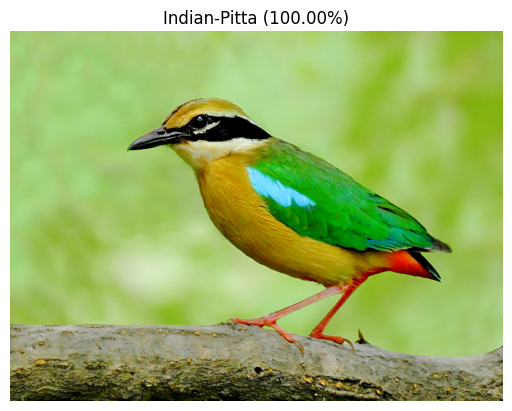

In [198]:
img = Image.open(IMG_PATH)
plt.imshow(img)
plt.title(f"{pred_label} ({confidence:.2%})")
plt.axis("off")
plt.show()


In [35]:
from torchvision import models
import torch.nn as nn

model_vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all conv layers first
for p in model_vgg.features.parameters():
    p.requires_grad = False


In [36]:
for p in model_vgg.features[24:].parameters():
    p.requires_grad = True


In [37]:
model_vgg.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.BatchNorm1d(4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(4096, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(1024, num_classes)
)

model_vgg = model_vgg.to(device)


In [38]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


In [39]:
import torch.optim as optim

optimizer = optim.AdamW([
    {"params": model_vgg.features[24:].parameters(), "lr": 1e-5},
    {"params": model_vgg.classifier.parameters(),   "lr": 1e-4}
], weight_decay=1e-4)


In [41]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=2,
)


In [42]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
 
    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix(loss=running_loss/total, acc=correct/total)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validate ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        scheduler.step(val_loss)

        print(f"\nEpoch {epoch+1}/{epochs} | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

    return history


In [43]:
history1 = train_model(model_vgg, train_loader, valid_loader, criterion, optimizer, epochs=CFG.EPOCHS)


Epoch 1/7: 100%|████████| 938/938 [12:41<00:00,  1.23it/s, acc=0.839, loss=1.18]



Epoch 1/7 | Train Loss 1.1809 Acc 0.8385 | Val Loss 0.8773 Acc 0.9363


Epoch 2/7: 100%|███████| 938/938 [12:32<00:00,  1.25it/s, acc=0.941, loss=0.882]



Epoch 2/7 | Train Loss 0.8815 Acc 0.9406 | Val Loss 0.8175 Acc 0.9564


Epoch 3/7: 100%|███████| 938/938 [12:51<00:00,  1.22it/s, acc=0.966, loss=0.808]


...


Epoch 5/7 | Train Loss 0.7452 Acc 0.9841 | Val Loss 0.7539 Acc 0.9697


Epoch 6/7: 100%|████████| 938/938 [13:21<00:00,  1.17it/s, acc=0.99, loss=0.723]



Epoch 6/7 | Train Loss 0.7227 Acc 0.9899 | Val Loss 0.7479 Acc 0.9713


Epoch 7/7: 100%|███████| 938/938 [13:26<00:00,  1.16it/s, acc=0.993, loss=0.711]



Epoch 7/7 | Train Loss 0.7107 Acc 0.9926 | Val Loss 0.7373 Acc 0.9745


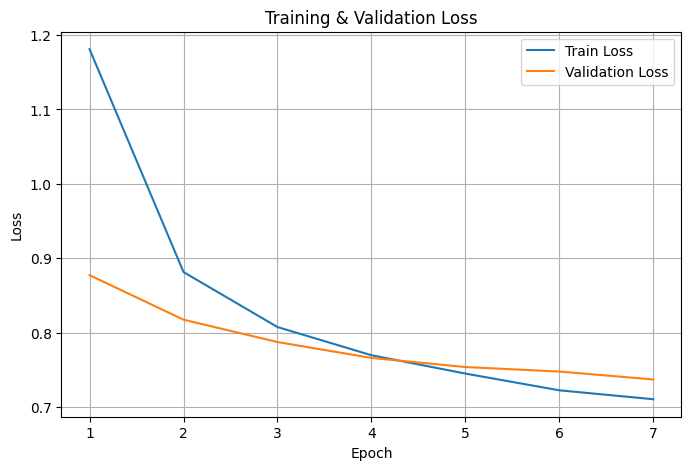

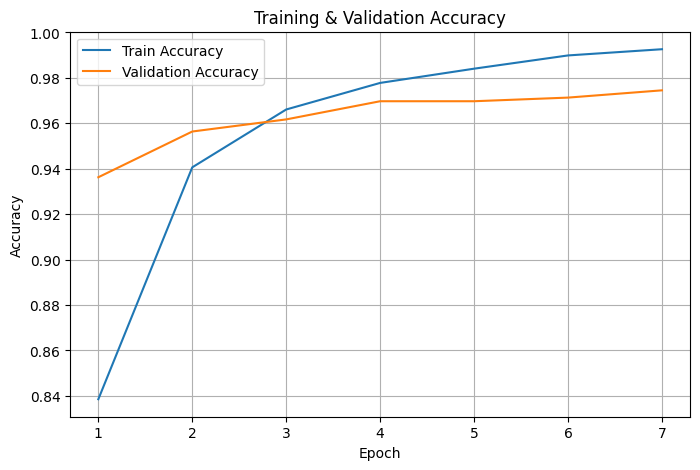

In [46]:
epochs = range(1, len(history1["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history1["train_loss"], label="Train Loss")
plt.plot(epochs, history1["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history1["train_acc"], label="Train Accuracy")
plt.plot(epochs, history1["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
MODEL_PATH = "vgg16_birds_updated.pth"

torch.save({
    "model_state_dict": model_vgg.state_dict(),
    "class_to_idx": train_dataset.class_to_idx
}, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

Model saved to vgg16_birds_updated.pth


In [49]:
MODEL_PATH = "vgg16_birds_updated.pth"


# Rebuild the same VGG architecture
model_loaded = models.vgg16(weights=None)
for p in model_vgg.features[24:].parameters():
    p.requires_grad = True
model_vgg.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.BatchNorm1d(4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(4096, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(1024, num_classes)  # will be set after loading
)
checkpoint = torch.load(MODEL_PATH, map_location=device)
num_classes = len(checkpoint["class_to_idx"])
model_vgg.classifier[-1] = nn.Linear(1024, num_classes)

model_vgg.load_state_dict(checkpoint["model_state_dict"])
model_vgg = model_vgg.to(device)
model_vgg.eval()
idx_to_class = {v: k for k, v in checkpoint["class_to_idx"].items()}
print("Classes loaded:", len(idx_to_class))
print(model_vgg.classifier)

Classes loaded: 25
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=1024, bias=True)
  (5): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): Dropout(p=0.5, inplace=False)
  (8): Linear(in_features=1024, out_features=25, bias=True)
)


In [201]:
from torchvision import transforms
from PIL import Image

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img = Image.open("/Users/marieta/Downloads/sample_img.jpg").convert("RGB")
x = val_transforms(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model_vgg(x)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(1).item()

print("Predicted:", idx_to_class[pred_idx])
print("Confidence:", round(probs[0, pred_idx].item(), 4))

Predicted: Indian-Pitta
Confidence: 0.9114


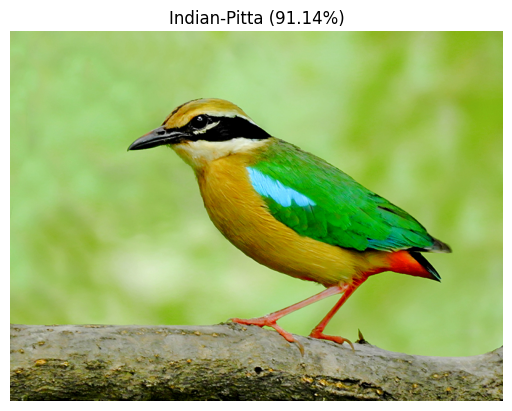

In [202]:
img = Image.open("/Users/marieta/Downloads/sample_img.jpg")
plt.imshow(img)
plt.title(f"{idx_to_class[pred_idx]} ({probs[0, pred_idx].item():.2%})")
plt.axis("off")
plt.show()

In [55]:
aux_logits=False
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [57]:
model_google1 = models.googlenet(
    weights=models.GoogLeNet_Weights.IMAGENET1K_V1,
    aux_logits=True
)
model_google1.aux_logits = False
model_google1.aux1 = None
model_google1.aux2 = None

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /Users/marieta/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100.0%
/Users/marieta/myenv/lib/python3.13/site-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


In [58]:
for p in model_google1.parameters():
    p.requires_grad = False


In [59]:
model_google1.fc = nn.Sequential(
    nn.Linear(model_google1.fc.in_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)


In [60]:
model_google1 = model_google1.to(device)


In [61]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_google1.fc.parameters(),
    lr=1e-4
)

In [62]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
 
    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix(loss=running_loss/total, acc=correct/total)

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validate ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        scheduler.step(val_loss)

        print(f"\nEpoch {epoch+1}/{epochs} | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

    return history

In [63]:
history2 = train_model(model_google1, train_loader, valid_loader, criterion, optimizer, epochs=CFG.EPOCHS)


Epoch 1/7: 100%|████████| 938/938 [03:58<00:00,  3.94it/s, acc=0.534, loss=1.96]



Epoch 1/7 | Train Loss 1.9601 Acc 0.5340 | Val Loss 1.0528 Acc 0.7619


Epoch 2/7: 100%|████████| 938/938 [03:56<00:00,  3.96it/s, acc=0.707, loss=1.06]



Epoch 2/7 | Train Loss 1.0646 Acc 0.7067 | Val Loss 0.7684 Acc 0.7941


Epoch 3/7: 100%|███████| 938/938 [03:56<00:00,  3.97it/s, acc=0.739, loss=0.899]


...


Epoch 5/7 | Train Loss 0.7845 Acc 0.7654 | Val Loss 0.5843 Acc 0.8300


Epoch 6/7: 100%|████████| 938/938 [03:43<00:00,  4.19it/s, acc=0.77, loss=0.757]



Epoch 6/7 | Train Loss 0.7570 Acc 0.7703 | Val Loss 0.5587 Acc 0.8360


Epoch 7/7: 100%|███████| 938/938 [03:59<00:00,  3.92it/s, acc=0.778, loss=0.727]



Epoch 7/7 | Train Loss 0.7270 Acc 0.7778 | Val Loss 0.5348 Acc 0.8421


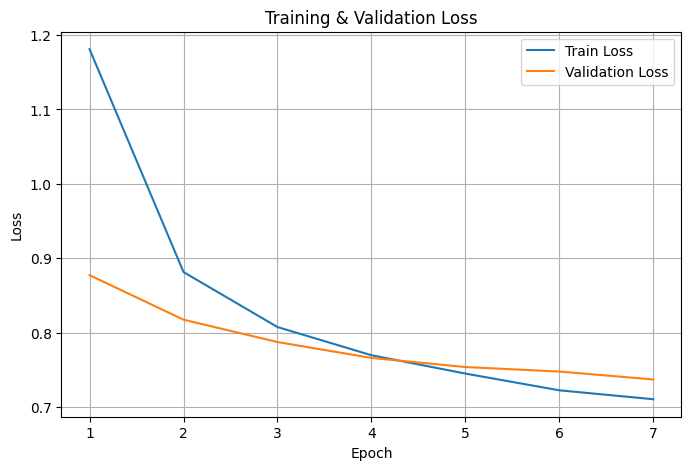

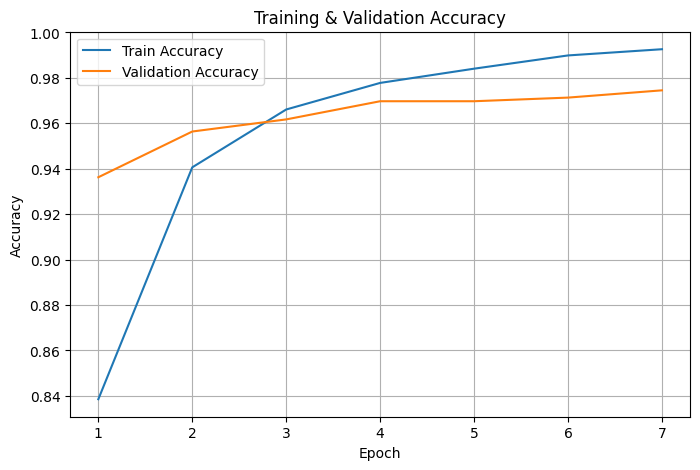

In [65]:
epochs = range(1, len(history1["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history1["train_loss"], label="Train Loss")
plt.plot(epochs, history1["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history1["train_acc"], label="Train Accuracy")
plt.plot(epochs, history1["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
MODEL_PATH = "googlenet_birds.pth"

torch.save({
    "model_state_dict": model_google1.state_dict(),
    "class_to_idx": train_dataset.class_to_idx,
    "arch": "googlenet_inception_v1_custom_fc"
}, MODEL_PATH)

print(f"GoogLeNet model saved to {MODEL_PATH}")


GoogLeNet model saved to googlenet_birds.pth


In [71]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)
checkpoint = torch.load("googlenet_birds.pth", map_location=device)

num_classes = len(checkpoint["class_to_idx"])
model_google1 = models.googlenet(
    weights=models.GoogLeNet_Weights.IMAGENET1K_V1
)
in_features = model_google.fc.in_features

model_google1.aux_logits = False
model_google1.aux1 = None
model_google1.aux2 = None
model_google1.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

model_google1.load_state_dict(checkpoint["model_state_dict"])
model_google1 = model_google1.to(device)
model_google1.eval()
idx_to_class = {v: k for k, v in checkpoint["class_to_idx"].items()}
print("Classes loaded:", len(idx_to_class))

Device: mps
Classes loaded: 25


In [209]:
from torchvision import transforms
from PIL import Image

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img = Image.open("/Users/marieta/Downloads/sample_img2.jpeg").convert("RGB")
x = val_transforms(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model_google1(x)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(1).item()

print("Predicted bird:", idx_to_class[pred_idx])
print("Confidence:", round(probs[0, pred_idx].item(), 4))


Predicted bird: Jungle-Babbler
Confidence: 0.8412


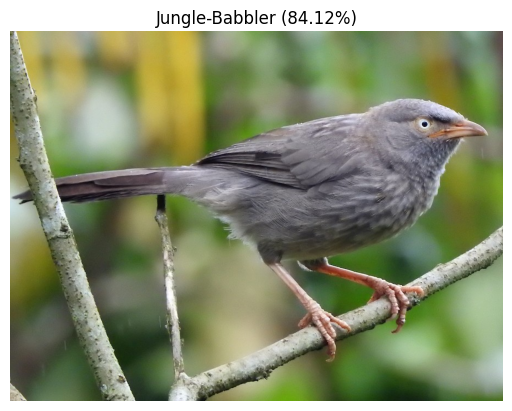

In [210]:
img = Image.open("/Users/marieta/Downloads/sample_img2.jpeg")
plt.imshow(img)
plt.title(f"{idx_to_class[pred_idx]} ({probs[0, pred_idx].item():.2%})")
plt.axis("off")
plt.show()

In [171]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [172]:
model = models.googlenet(
    weights=models.GoogLeNet_Weights.IMAGENET1K_V1
)
model.aux_logits = False
model.aux1 = None
model.aux2 = None

# replace classifier
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),

    nn.Linear(256, num_classes)
)


In [173]:
# 1. Freeze everything
for p in model.parameters():
    p.requires_grad = False

# 2. Unfreeze classifier
for p in model.fc.parameters():
    p.requires_grad = True

# 3. Unfreeze last Inception block
for p in model.inception5b.parameters():
    p.requires_grad = True


In [174]:
model = model.to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


In [175]:
history3 = train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    epochs=7
)

Epoch 1/7: 100%|████████| 938/938 [03:49<00:00,  4.08it/s, acc=0.554, loss=1.81]



Epoch 1/7 | Train Loss 1.8118 Acc 0.5544 | Val Loss 0.8325 Acc 0.8233


Epoch 2/7: 100%|███████| 938/938 [03:47<00:00,  4.13it/s, acc=0.775, loss=0.872]



Epoch 2/7 | Train Loss 0.8717 Acc 0.7751 | Val Loss 0.4948 Acc 0.8676


Epoch 3/7: 100%|███████| 938/938 [03:48<00:00,  4.10it/s, acc=0.819, loss=0.646]


...


Epoch 5/7 | Train Loss 0.4777 Acc 0.8589 | Val Loss 0.3097 Acc 0.9085


Epoch 6/7: 100%|███████| 938/938 [04:02<00:00,  3.86it/s, acc=0.871, loss=0.431]



Epoch 6/7 | Train Loss 0.4305 Acc 0.8707 | Val Loss 0.2911 Acc 0.9127


Epoch 7/7: 100%|████████| 938/938 [04:03<00:00,  3.84it/s, acc=0.88, loss=0.399]



Epoch 7/7 | Train Loss 0.3986 Acc 0.8798 | Val Loss 0.2823 Acc 0.9148


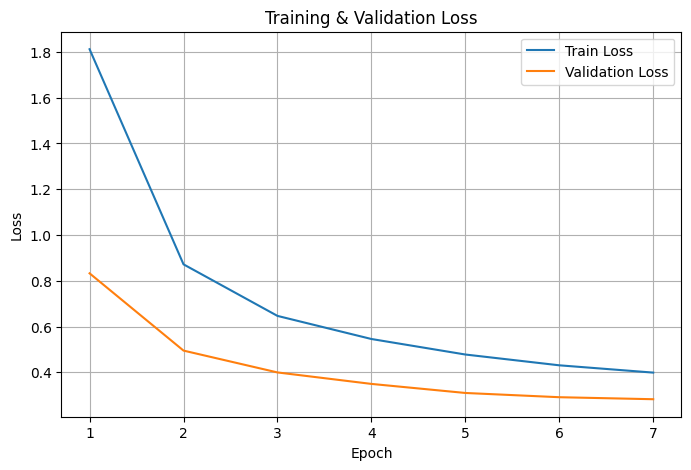

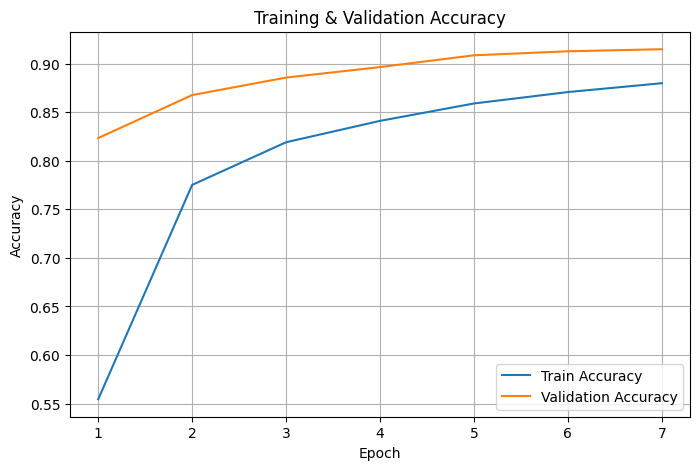

In [176]:
epochs = range(1, len(history3["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history3["train_loss"], label="Train Loss")
plt.plot(epochs, history3["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history3["train_acc"], label="Train Accuracy")
plt.plot(epochs, history3["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [177]:
MODEL_PATH = "googlenet_birds_updated.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": train_dataset.class_to_idx,
    "arch": "googlenet_inception_v1_updated"
}, MODEL_PATH)

print(f"GoogLeNet model saved to {MODEL_PATH}")


GoogLeNet model saved to googlenet_birds_updated.pth


In [192]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)
# Load checkpoint
checkpoint = torch.load("googlenet_birds.pth", map_location=device)

# Number of classes
num_classes = len(checkpoint["class_to_idx"])

# Build GoogLeNet WITHOUT pretrained aux heads
model = models.googlenet(
    weights=models.GoogLeNet_Weights.IMAGENET1K_V1,
    aux_logits=True
)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),

    nn.Linear(256, num_classes)
)

# Load weights SAFELY (ignore mismatched fc)
model.load_state_dict(checkpoint["model_state_dict"], strict=False)

# Move model to device
model = model.to(device)
model.eval()

# Restore class mapping
idx_to_class = {v: k for k, v in checkpoint["class_to_idx"].items()}

print("Classes loaded:", len(idx_to_class))


Device: mps
Classes loaded: 25


In [207]:
from torchvision import transforms
from PIL import Image

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

img = Image.open("/Users/marieta/Downloads/sample_img2.jpeg").convert("RGB")
x = val_transforms(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(1).item()

print("Predicted bird:", idx_to_class[pred_idx])
print("Confidence:", round(probs[0, pred_idx].item(), 4))


Predicted bird: Northern-Lapwing
Confidence: 0.0731


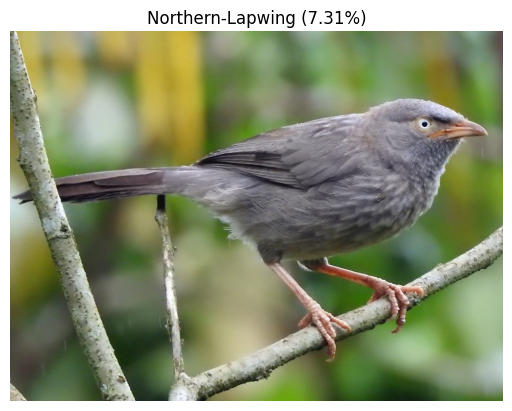

In [208]:
img = Image.open("/Users/marieta/Downloads/sample_img2.jpeg")
plt.imshow(img)
plt.title(f"{idx_to_class[pred_idx]} ({probs[0, pred_idx].item():.2%})")
plt.axis("off")
plt.show()